DATASET INFORMATION
Dataset shape: (569, 32)

First five rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ..

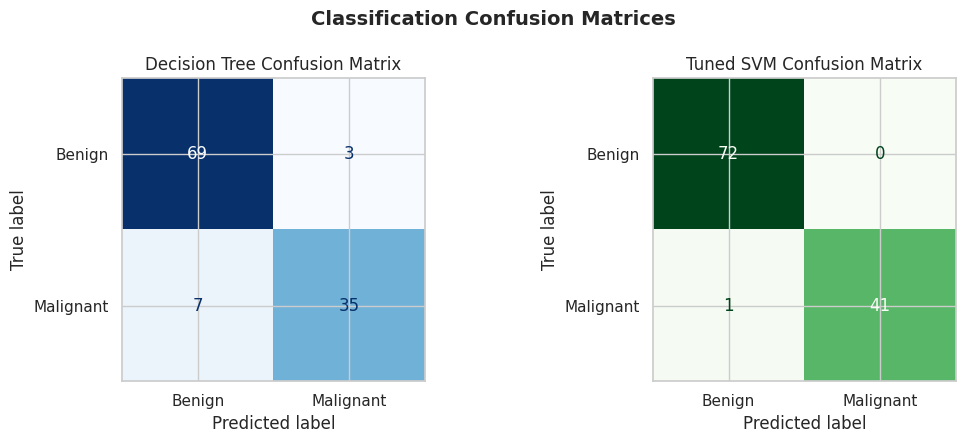

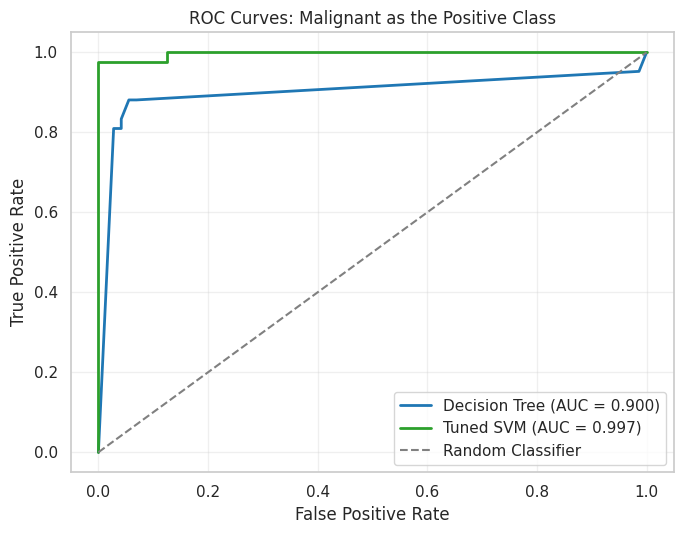


SILHOUETTE SCORES
 Number of Clusters  Silhouette Score
                  2            0.3450
                  3            0.3144
                  4            0.2803
                  5            0.1585
                  6            0.1604

Best number of clusters: 2
Final silhouette score: 0.3450

CLUSTER PROFILE BY DIAGNOSIS
diagnosis  benign  malignant  Total  Malignant Rate
cluster                                            
0              14        175    189          0.9259
1             343         37    380          0.0974

Most distinguishing features in each cluster:

Cluster 0 — five elevated features:
mean concave points     1.164
worst concave points    1.145
mean concavity          1.138
worst perimeter         1.065
worst concavity         1.043
dtype: float64

Cluster 0 — five reduced features:
smoothness error           0.017
texture error              0.043
symmetry error             0.140
mean fractal dimension     0.252
fractal dimension error    0.415
dtype:

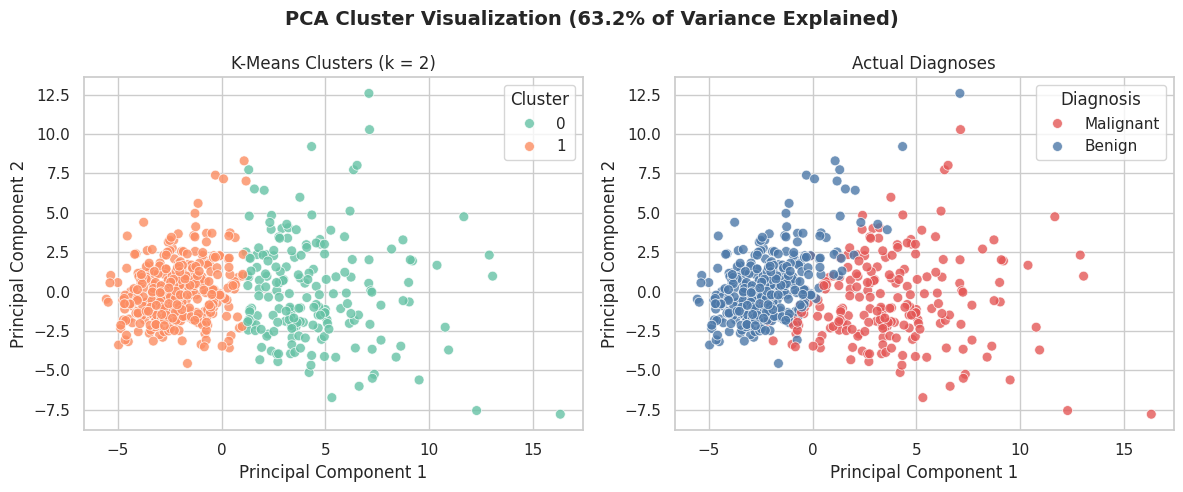


TOP ASSOCIATION RULES WITH DIAGNOSIS AS THE OUTCOME
                                   Antecedent          Consequent  Support  Confidence   Lift
        worst area=High, worst concavity=High Diagnosis=Malignant   0.3427      0.8784 2.3575
         mean concavity=High, worst area=High Diagnosis=Malignant   0.3409      0.8778 2.3561
      worst concavity=High, worst radius=High Diagnosis=Malignant   0.3427      0.8744 2.3470
       mean concavity=High, worst radius=High Diagnosis=Malignant   0.3409      0.8739 2.3454
       mean radius=High, worst concavity=High Diagnosis=Malignant   0.3234      0.8679 2.3295
        mean concavity=High, mean radius=High Diagnosis=Malignant   0.3216      0.8632 2.3168
         mean texture=High, worst radius=High Diagnosis=Malignant   0.2865      0.8624 2.3147
 mean texture=High, worst concave points=High Diagnosis=Malignant   0.2777      0.8587 2.3047
    mean concavity=High, worst perimeter=High Diagnosis=Malignant   0.3409      0.8584 2.3039
       

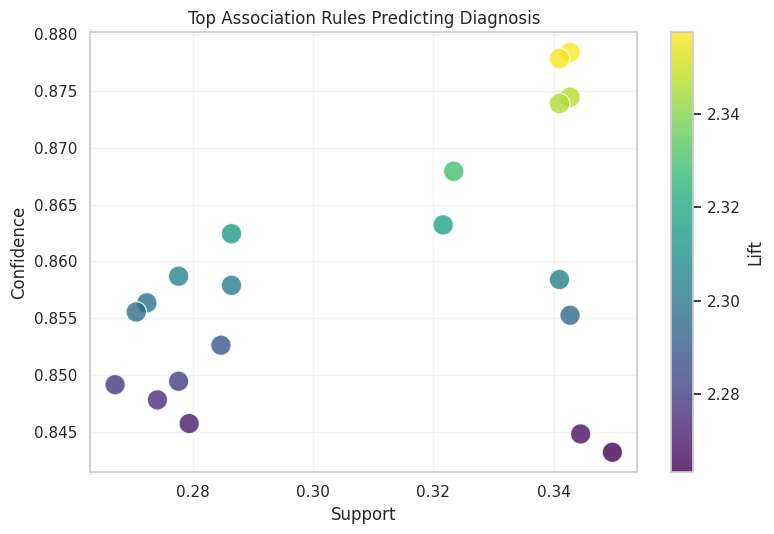


KEY FINDINGS AND REAL-WORLD APPLICATION

1. The best classification model was Tuned SVM.
   It achieved an accuracy of 0.9912,
   an F1 score of 0.9880, and an ROC-AUC
   of 0.9970 on the holdout test dataset.

2. Hyperparameter tuning selected the following SVM parameters:
   {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}

3. The clustering analysis selected 2 clusters based on the
   highest silhouette score of 0.3450. The clusters
   separate records with relatively high tumor size, concavity, and
   concave-point measurements from records with lower measurements.

4. Association rules identify combinations of high measurements that
   frequently occur with malignant diagnoses. Rules with confidence
   close to 1 indicate that the diagnosis outcome often appears when
   the antecedent measurements occur. Lift greater than 1 indicates
   that the relationship is stronger than random co-occurrence.

5. In a real healthcare setting, these models could support clinical
   dec

In [4]:
# ============================================================
# DELIVERABLE 3: CLASSIFICATION, CLUSTERING, AND PATTERN MINING
# Dataset: wisconsin_breast_cancer_raw(1).csv
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    silhouette_score
)

# ------------------------------------------------------------
# 1. LOAD THE DATASET
# ------------------------------------------------------------

file_path = "wisconsin_breast_cancer_raw.csv"
df = pd.read_csv(file_path)

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)
print("Dataset shape:", df.shape)
print("\nFirst five rows:")
print(df.head())

print("\nMissing values:", df.isnull().sum().sum())
print("\nDiagnosis distribution:")
print(df["diagnosis"].value_counts())

# ------------------------------------------------------------
# 2. PREPARE FEATURES AND TARGET
# ------------------------------------------------------------

# Exclude both diagnosis columns from the predictor variables.
feature_columns = [
    column for column in df.columns
    if column not in ["diagnosis", "diagnosis_code"]
]

X = df[feature_columns].copy()

# Malignant is defined as the positive class (1).
y = (
    df["diagnosis"]
    .astype(str)
    .str.lower()
    .eq("malignant")
    .astype(int)
)

print("\nTarget coding:")
print("0 = Benign")
print("1 = Malignant")

# Stratified splitting preserves the class proportions.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining records:", len(X_train))
print("Testing records:", len(X_test))

# ------------------------------------------------------------
# 3. CLASSIFICATION MODEL 1: DECISION TREE
# ------------------------------------------------------------

decision_tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42
)

decision_tree.fit(X_train, y_train)

tree_predictions = decision_tree.predict(X_test)
tree_probabilities = decision_tree.predict_proba(X_test)[:, 1]

tree_accuracy = accuracy_score(y_test, tree_predictions)
tree_f1 = f1_score(y_test, tree_predictions)
tree_auc = roc_auc_score(y_test, tree_probabilities)

print("\n" + "=" * 70)
print("DECISION TREE RESULTS")
print("=" * 70)
print(f"Accuracy: {tree_accuracy:.4f}")
print(f"F1 Score: {tree_f1:.4f}")
print(f"ROC-AUC:  {tree_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        tree_predictions,
        target_names=["Benign", "Malignant"]
    )
)

# ------------------------------------------------------------
# 4. CLASSIFICATION MODEL 2: SVM WITH HYPERPARAMETER TUNING
# ------------------------------------------------------------

# Scaling is performed inside the pipeline to prevent data leakage.
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "svm",
        SVC(
            probability=True,
            class_weight="balanced",
            random_state=42
        )
    )
])

# Values tested through GridSearchCV.
parameter_grid = {
    "svm__kernel": ["rbf"],
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.001, 0.01, 0.1]
}

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=parameter_grid,
    scoring="f1",
    cv=cross_validation,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

best_svm = grid_search.best_estimator_

svm_predictions = best_svm.predict(X_test)
svm_probabilities = best_svm.predict_proba(X_test)[:, 1]

svm_accuracy = accuracy_score(y_test, svm_predictions)
svm_f1 = f1_score(y_test, svm_predictions)
svm_auc = roc_auc_score(y_test, svm_probabilities)

print("\n" + "=" * 70)
print("TUNED SVM RESULTS")
print("=" * 70)
print("Best hyperparameters:", grid_search.best_params_)
print(f"Best cross-validation F1: {grid_search.best_score_:.4f}")
print(f"Test Accuracy: {svm_accuracy:.4f}")
print(f"Test F1 Score: {svm_f1:.4f}")
print(f"Test ROC-AUC:  {svm_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        svm_predictions,
        target_names=["Benign", "Malignant"]
    )
)

# ------------------------------------------------------------
# 5. CLASSIFICATION MODEL COMPARISON
# ------------------------------------------------------------

classification_results = pd.DataFrame({
    "Model": ["Decision Tree", "Tuned SVM"],
    "Accuracy": [tree_accuracy, svm_accuracy],
    "F1 Score": [tree_f1, svm_f1],
    "ROC-AUC": [tree_auc, svm_auc]
})

print("\n" + "=" * 70)
print("CLASSIFICATION MODEL COMPARISON")
print("=" * 70)
print(classification_results.round(4).to_string(index=False))

classification_results.to_csv(
    "classification_model_results.csv",
    index=False
)

# ------------------------------------------------------------
# 6. CONFUSION MATRICES
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, tree_predictions),
    display_labels=["Benign", "Malignant"]
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False,
    values_format="d"
)

axes[0].set_title("Decision Tree Confusion Matrix")

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, svm_predictions),
    display_labels=["Benign", "Malignant"]
).plot(
    ax=axes[1],
    cmap="Greens",
    colorbar=False,
    values_format="d"
)

axes[1].set_title("Tuned SVM Confusion Matrix")

plt.suptitle(
    "Classification Confusion Matrices",
    fontsize=14,
    fontweight="bold"
)
plt.tight_layout()
plt.savefig(
    "confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ------------------------------------------------------------
# 7. ROC CURVES
# ------------------------------------------------------------

tree_fpr, tree_tpr, _ = roc_curve(
    y_test,
    tree_probabilities
)

svm_fpr, svm_tpr, _ = roc_curve(
    y_test,
    svm_probabilities
)

plt.figure(figsize=(7, 5.5))

plt.plot(
    tree_fpr,
    tree_tpr,
    linewidth=2,
    label=f"Decision Tree (AUC = {tree_auc:.3f})",
    color="#1f77b4"
)

plt.plot(
    svm_fpr,
    svm_tpr,
    linewidth=2,
    label=f"Tuned SVM (AUC = {svm_auc:.3f})",
    color="#2ca02c"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Malignant as the Positive Class")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "roc_curves.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ------------------------------------------------------------
# 8. K-MEANS CLUSTERING
# ------------------------------------------------------------

# K-Means is distance-based, so all features must be standardized.
clustering_scaler = StandardScaler()
X_scaled = clustering_scaler.fit_transform(X)

# Test k values from 2 through 6 using silhouette scores.
silhouette_results = []

for k in range(2, 7):
    temporary_kmeans = KMeans(
        n_clusters=k,
        n_init=25,
        random_state=42
    )

    temporary_labels = temporary_kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        temporary_labels
    )

    silhouette_results.append({
        "Number of Clusters": k,
        "Silhouette Score": score
    })

silhouette_table = pd.DataFrame(silhouette_results)

print("\n" + "=" * 70)
print("SILHOUETTE SCORES")
print("=" * 70)
print(silhouette_table.round(4).to_string(index=False))

best_k = int(
    silhouette_table.loc[
        silhouette_table["Silhouette Score"].idxmax(),
        "Number of Clusters"
    ]
)

print("\nBest number of clusters:", best_k)

# Fit the final K-Means model.
kmeans = KMeans(
    n_clusters=best_k,
    n_init=50,
    random_state=42
)

cluster_labels = kmeans.fit_predict(X_scaled)

df["cluster"] = cluster_labels

best_silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

print(f"Final silhouette score: {best_silhouette:.4f}")

# ------------------------------------------------------------
# 9. CLUSTER PROFILES
# ------------------------------------------------------------

cluster_profile = pd.crosstab(
    df["cluster"],
    df["diagnosis"]
)

cluster_profile["Total"] = cluster_profile.sum(axis=1)

if "malignant" in cluster_profile.columns:
    cluster_profile["Malignant Rate"] = (
        cluster_profile["malignant"]
        / cluster_profile["Total"]
    )

print("\n" + "=" * 70)
print("CLUSTER PROFILE BY DIAGNOSIS")
print("=" * 70)
print(cluster_profile.round(4))

cluster_profile.to_csv("cluster_profile.csv")

# Identify the five most elevated features in each cluster.
cluster_feature_means = (
    df.groupby("cluster")[feature_columns]
    .mean()
)

overall_feature_means = df[feature_columns].mean()
overall_feature_standard_deviations = df[feature_columns].std()

print("\nMost distinguishing features in each cluster:")

for cluster_number in sorted(df["cluster"].unique()):
    standardized_differences = (
        (
            cluster_feature_means.loc[cluster_number]
            - overall_feature_means
        )
        / overall_feature_standard_deviations
    ).sort_values(ascending=False)

    print(f"\nCluster {cluster_number} — five elevated features:")
    print(standardized_differences.head(5).round(3))

    print(f"\nCluster {cluster_number} — five reduced features:")
    print(
        standardized_differences
        .tail(5)
        .sort_values()
        .round(3)
    )

# ------------------------------------------------------------
# 10. PCA VISUALIZATION OF CLUSTERS
# ------------------------------------------------------------

pca = PCA(
    n_components=2,
    random_state=42
)

principal_components = pca.fit_transform(X_scaled)

cluster_visualization = pd.DataFrame({
    "Principal Component 1": principal_components[:, 0],
    "Principal Component 2": principal_components[:, 1],
    "Cluster": cluster_labels.astype(str),
    "Diagnosis": df["diagnosis"].str.title()
})

explained_variance = pca.explained_variance_ratio_.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    data=cluster_visualization,
    x="Principal Component 1",
    y="Principal Component 2",
    hue="Cluster",
    palette="Set2",
    s=50,
    alpha=0.80,
    ax=axes[0]
)

axes[0].set_title(f"K-Means Clusters (k = {best_k})")

sns.scatterplot(
    data=cluster_visualization,
    x="Principal Component 1",
    y="Principal Component 2",
    hue="Diagnosis",
    palette={
        "Benign": "#4C78A8",
        "Malignant": "#E45756"
    },
    s=50,
    alpha=0.80,
    ax=axes[1]
)

axes[1].set_title("Actual Diagnoses")

plt.suptitle(
    f"PCA Cluster Visualization "
    f"({explained_variance:.1%} of Variance Explained)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    "kmeans_cluster_visualization.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ------------------------------------------------------------
# 11. ASSOCIATION RULE MINING
# ------------------------------------------------------------

# This function performs Apriori-style frequent itemset and rule mining
# without requiring an additional mlxtend installation.

def generate_association_rules(
    transactions,
    minimum_support=0.10,
    minimum_confidence=0.70,
    maximum_itemset_length=3
):
    transaction_sets = [
        set(transaction)
        for transaction in transactions
    ]

    number_of_transactions = len(transaction_sets)

    all_items = sorted(
        set().union(*transaction_sets)
    )

    support_values = {}
    frequent_itemsets = {}

    # Find frequent itemsets.
    for itemset_length in range(
        1,
        maximum_itemset_length + 1
    ):
        frequent_itemsets[itemset_length] = []

        candidates = itertools.combinations(
            all_items,
            itemset_length
        )

        for candidate in candidates:
            candidate_set = frozenset(candidate)

            support = sum(
                candidate_set.issubset(transaction)
                for transaction in transaction_sets
            ) / number_of_transactions

            if support >= minimum_support:
                support_values[candidate_set] = support

                frequent_itemsets[
                    itemset_length
                ].append(candidate_set)

    discovered_rules = []

    # Generate rules from the frequent itemsets.
    for itemset_length, itemsets in frequent_itemsets.items():

        if itemset_length < 2:
            continue

        for itemset in itemsets:

            for antecedent_size in range(
                1,
                len(itemset)
            ):

                antecedent_combinations = itertools.combinations(
                    itemset,
                    antecedent_size
                )

                for antecedent_items in antecedent_combinations:
                    antecedent = frozenset(antecedent_items)
                    consequent = itemset - antecedent

                    if (
                        antecedent not in support_values
                        or consequent not in support_values
                    ):
                        continue

                    confidence = (
                        support_values[itemset]
                        / support_values[antecedent]
                    )

                    lift = (
                        confidence
                        / support_values[consequent]
                    )

                    if (
                        confidence >= minimum_confidence
                        and lift > 1
                    ):
                        discovered_rules.append({
                            "Antecedent": ", ".join(
                                sorted(antecedent)
                            ),
                            "Consequent": ", ".join(
                                sorted(consequent)
                            ),
                            "Support": support_values[itemset],
                            "Confidence": confidence,
                            "Lift": lift
                        })

    rules_dataframe = pd.DataFrame(discovered_rules)

    if not rules_dataframe.empty:
        rules_dataframe = (
            rules_dataframe
            .drop_duplicates()
            .sort_values(
                by=[
                    "Lift",
                    "Confidence",
                    "Support"
                ],
                ascending=False
            )
            .reset_index(drop=True)
        )

    return rules_dataframe

# Select interpretable measurements for association-rule mining.
association_features = [
    "mean radius",
    "mean texture",
    "mean concavity",
    "mean concave points",
    "worst radius",
    "worst texture",
    "worst perimeter",
    "worst area",
    "worst concavity",
    "worst concave points"
]

# Continuous measurements are converted into high/low categories
# using the median for each variable.
feature_medians = df[association_features].median()

transactions = []

for _, row in df.iterrows():
    transaction = []

    for feature in association_features:
        if row[feature] >= feature_medians[feature]:
            transaction.append(f"{feature}=High")
        else:
            transaction.append(f"{feature}=Low")

    transaction.append(
        f"Diagnosis={str(row['diagnosis']).title()}"
    )

    transactions.append(transaction)

association_rules = generate_association_rules(
    transactions=transactions,
    minimum_support=0.10,
    minimum_confidence=0.70,
    maximum_itemset_length=3
)

# Retain rules where diagnosis is the outcome.
diagnosis_rules = association_rules[
    association_rules["Consequent"].str.contains(
        "Diagnosis=",
        na=False
    )
].copy()

print("\n" + "=" * 70)
print("TOP ASSOCIATION RULES WITH DIAGNOSIS AS THE OUTCOME")
print("=" * 70)

print(
    diagnosis_rules.head(15)
    .round(4)
    .to_string(index=False)
)

diagnosis_rules.to_csv(
    "diagnosis_association_rules.csv",
    index=False
)

# ------------------------------------------------------------
# 12. ASSOCIATION RULE VISUALIZATION
# ------------------------------------------------------------

if not diagnosis_rules.empty:
    top_rules = diagnosis_rules.head(20).copy()

    plt.figure(figsize=(8, 5.5))

    scatter = plt.scatter(
        top_rules["Support"],
        top_rules["Confidence"],
        s=80 + (top_rules["Lift"] * 60),
        c=top_rules["Lift"],
        cmap="viridis",
        alpha=0.80,
        edgecolors="white"
    )

    plt.colorbar(
        scatter,
        label="Lift"
    )

    plt.xlabel("Support")
    plt.ylabel("Confidence")
    plt.title(
        "Top Association Rules Predicting Diagnosis"
    )
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(
        "association_rule_visualization.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

# ------------------------------------------------------------
# 13. PRACTICAL INTERPRETATION
# ------------------------------------------------------------

best_model_row = classification_results.loc[
    classification_results["F1 Score"].idxmax()
]

print("\n" + "=" * 70)
print("KEY FINDINGS AND REAL-WORLD APPLICATION")
print("=" * 70)

print(
    f"""
1. The best classification model was {best_model_row['Model']}.
   It achieved an accuracy of {best_model_row['Accuracy']:.4f},
   an F1 score of {best_model_row['F1 Score']:.4f}, and an ROC-AUC
   of {best_model_row['ROC-AUC']:.4f} on the holdout test dataset.

2. Hyperparameter tuning selected the following SVM parameters:
   {grid_search.best_params_}

3. The clustering analysis selected {best_k} clusters based on the
   highest silhouette score of {best_silhouette:.4f}. The clusters
   separate records with relatively high tumor size, concavity, and
   concave-point measurements from records with lower measurements.

4. Association rules identify combinations of high measurements that
   frequently occur with malignant diagnoses. Rules with confidence
   close to 1 indicate that the diagnosis outcome often appears when
   the antecedent measurements occur. Lift greater than 1 indicates
   that the relationship is stronger than random co-occurrence.

5. In a real healthcare setting, these models could support clinical
   decision-making by identifying high-risk records for additional
   examination. Clustering could assist with patient segmentation,
   while association rules could reveal understandable combinations
   of tumor characteristics. However, these results should support,
   not replace, professional medical diagnosis.
"""
)

print("=" * 70)
print("ANALYSIS COMPLETED")
print("=" * 70)

print(
    """
Generated files:
1. classification_model_results.csv
2. confusion_matrices.png
3. roc_curves.png
4. cluster_profile.csv
5. kmeans_cluster_visualization.png
6. diagnosis_association_rules.csv
7. association_rule_visualization.png
"""
)
